# Proyek Analisis Data: [Input Nama Dataset]
- **Nama:** Muhammad Ilham Fadly
- **Email:** muhammadilhamfadly@gmail.com
- **ID Dicoding:** CDCC009D6Y1009

## Menentukan Pertanyaan Bisnis

- Bagaimana perbedaan rata-rata jumlah penyewaan sepeda pada setiap kondisi cuaca sepanjang tahun 2011-2012?
- Pada jam berapa rata-rata penyewaan sepeda mencapai tingkat tertinggi dalam satu hari selama periode 2011-2012?

## Import Semua Packages/Library yang Digunakan

In [1]:
# Mengimpor semua library yang dibutuhkan untuk analisis data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [2]:
# Mengimpor data dari file eksternal (csv) ke dalam program python
day_df = pd.read_csv('day.csv')

# Menampilkan 5 baris pertama dari Dataframe tersebut
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [3]:
# Mengimpor data dari file eksternal (csv) ke dalam program python
hour_df = pd.read_csv('hour.csv')

# Menampilkan 5 baris pertama dari Dataframe tersebut
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- Dataset day.csv dan hour.csv berhasil dimuat dan menampilkan informasi penyewaan sepeda berdasarkan dua tingkat waktu, yaitu harian dan per jam. Dataset ini memungkinkan analisis pola penggunaan sepeda secara lebih luas, baik untuk melihat tren jangka panjang (harian) maupun pola aktivitas pengguna dalam satu hari (per jam).
- Dataset tidak hanya mencatat jumlah penyewaan sepeda (cnt), tetapi juga menyertakan berbagai faktor lingkungan seperti suhu (temp), kelembaban (hum), kecepatan angin (windspeed), serta kondisi cuaca (weathersit). Hal ini menunjukkan bahwa dataset dapat digunakan untuk menganalisis pengaruh kondisi cuaca dan lingkungan terhadap jumlah penyewaan sepeda.
- Dataset juga menyediakan informasi terkait faktor waktu dan jenis pengguna, seperti musim (season), bulan (mnth), hari dalam minggu (weekday), hari kerja (workingday), serta jumlah pengguna casual dan registered. Informasi ini memungkinkan analisis lebih lanjut mengenai pola penggunaan sepeda berdasarkan waktu serta perbedaan perilaku antara pengguna kasual dan pengguna terdaftar.


### Assessing Data

In [4]:
# Memeriksa tipe data dari setiap kolom
day_df.info()
print("========================================")
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (tot

In [5]:
# Cek Missing Value dari dataset
print("Missing Value dataset day.csv:\n", day_df.isnull().sum())
print("\nMissing Value dataset hour.csv:\n", hour_df.isnull().sum())

Missing Value dataset day.csv:
 instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

Missing Value dataset hour.csv:
 instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


In [6]:
# Cek duplikasi data menggunakan 'duplicated()'
day_df.duplicated().sum()
hour_df.duplicated().sum()

np.int64(0)

In [7]:
# Cek statistik deskriptif data
day_df.describe()
hour_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Insight:**
- Hasil pengecekan dari kedua dataset menggunakan (.info()) menunjukkan bahwa tipe data dteday adalah object, tipe data tersebut kurang tepat untuk kolom yang menunjukkan waktu. Maka, tipe data dteday akan di ganti menjadi datetime di bagian cleaning data.
- Hasil pemeriksaan missing value pada dataset day.csv dan hour.csv menunjukkan bahwa seluruh kolom memiliki nilai 0 missing value. Hal ini menunjukkan bahwa dataset berada dalam kondisi lengkap sehingga tidak diperlukan proses penanganan data kosong sebelum dilakukan analisis lebih lanjut.
- Berdasarkan hasil pemeriksaan data duplikat serta analisis statistik deskriptif, tidak ditemukan data duplikat maupun nilai yang tidak wajar seperti nilai negatif pada variabel numerik. Hal ini menunjukkan bahwa kualitas data pada kedua dataset cukup baik dan siap digunakan untuk tahap analisis berikutnya.

### Cleaning Data

In [8]:
# Mengubah tipe data 'dteday' menjadi datetime
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

# Cek perubahan
day_df.info()
print("========================================")
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    int64         
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    int64         
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    int64         
 7   workingday  731 non-null    int64         
 8   weathersit  731 non-null    int64         
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: datetime64[ns](1), floa

In [9]:
# Mapping musim (season)
season_labels = {
    1: 'Spring',
    2: 'Summer',
    3: 'Fall',
    4: 'Winter'
}

# Mapping cuaca (weathersit)
weather_labels = {
    1: 'Clear',
    2: 'Cloudy',
    3: 'Light Snow/Rain',
    4: 'Heavy Rain'
}

# Menerapkan mapping pada day_df
day_df['season'] = day_df['season'].map(season_labels)
day_df['weathersit'] = day_df['weathersit'].map(weather_labels)

# Menerapkan mapping pada hour_df
hour_df['season'] = hour_df['season'].map(season_labels)
hour_df['weathersit'] = hour_df['weathersit'].map(weather_labels)

# Cek perubahan
print("Musim :", day_df['season'].unique())
print("Cuaca :", day_df['weathersit'].unique())

Musim : ['Spring' 'Summer' 'Fall' 'Winter']
Cuaca : ['Cloudy' 'Clear' 'Light Snow/Rain']


**Insight:**
- Kolom dteday telah di konversi menjadi tipe data datetime. Dengan perubahan ini, sistem kini dapat mengenali urutan waktu (tahun, bulan, dan hari) secara otomatis. Hal ini memungkinkan proses ekstraksi tren penyewaan sepeda dilakukan dengan lebih akurat, sehingga pertanyaan bisnis mengenai pertumbuhan dari tahun ke tahun dapat dijawab dengan validitas yang lebih tinggi dibandingkan jika data tetap bertipe teks (object).
- Proses pemetaan (mapping) pada kolom season dan weathersit bertujuan untuk mempermudah dalam membaca dan kejelasan kontekstual pada dataset. Dengan mengubah angka menjadi label deskriptif (seperti 'Spring' atau 'Clear'), kita dapat mengidentifikasi distribusi data secara lebih intuitif, termasuk temuan bahwa kondisi cuaca ekstrem memiliki frekuensi yang sangat rendah dalam dataset ini.

## Exploratory Data Analysis (EDA)

### Explore ...

In [10]:
# Melihat rangkuman parameter statistik dari kedua dataset
day_df.describe(include="all")
hour_df.describe(include="all")

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
unique,NaN,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Fall,NaN,NaN,NaN,NaN,NaN,NaN,Clear,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,4496,NaN,NaN,NaN,NaN,NaN,NaN,11413,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,8690.0000,2012-01-02 04:08:34.552045568,NaN,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,NaN,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
min,1.0000,2011-01-01 00:00:00,NaN,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2011-07-04 00:00:00,NaN,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,NaN,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,2012-01-02 00:00:00,NaN,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,NaN,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,2012-07-02 00:00:00,NaN,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,NaN,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,2012-12-31 00:00:00,NaN,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,NaN,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [11]:
# Mengelompokkan berdasarkan cuaca dan menghitung rata-rata penyewaan
weather_rentals = day_df.groupby('weathersit')['cnt'].mean().sort_values(ascending=False).reset_index()

# Menampilkan rata-rata penyewaan di setiap cuaca
print(weather_rentals)

        weathersit          cnt
0            Clear  4876.786177
1           Cloudy  4035.862348
2  Light Snow/Rain  1803.285714


In [12]:
# Mengelompokkan berdasarkan jam (hr) dan menghitung rata-rata penyewaan
hourly_rentals = hour_df.groupby('hr')['cnt'].mean().sort_values(ascending=False).reset_index()

# Menampilkan 5 besar jam tersibuk
print(hourly_rentals.head(5))

   hr         cnt
0  17  461.452055
1  18  425.510989
2   8  359.011004
3  16  311.983562
4  19  311.523352


In [13]:
# Melakukan seleksi kolom yang relevan dengan pertanyaan bisnis untuk melihat korelasi
relevant_day_cols = ['cnt', 'temp', 'atemp', 'hum', 'windspeed', 'yr']
relevant_hour_cols = ['cnt', 'hr', 'temp', 'atemp', 'hum', 'windspeed', 'registered', 'casual']

# Korelasi variabel numerik pada dataset harian (day_df) terhadap jumlah total penyewaan (cnt)
correlation_day = day_df[relevant_day_cols].corr()['cnt'].sort_values(ascending=False)

# Korelasi variabel numerik pada dataset per-jam (hour_df) terhadap jumlah total penyewaan (cnt)
correlation_hour = hour_df[relevant_hour_cols].corr()['cnt'].sort_values(ascending=False)

# Menampilkan hasil korelasi
print(correlation_day)
print("=========================================")
print(correlation_hour)

cnt          1.000000
atemp        0.631066
temp         0.627494
yr           0.566710
hum         -0.100659
windspeed   -0.234545
Name: cnt, dtype: float64
cnt           1.000000
registered    0.972151
casual        0.694564
temp          0.404772
atemp         0.400929
hr            0.394071
windspeed     0.093234
hum          -0.322911
Name: cnt, dtype: float64


**Insight:**
- Analisis data menunjukkan bahwa volume penyewaan sepeda sangat bergantung pada kombinasi kondisi cuaca dan siklus aktivitas harian, di mana cuaca cerah (Clear) mendorong penggunaan tertinggi dengan rata-rata 4.876 penyewaan, sedangkan jam sibuk pada pukul 17:00, 18:00, dan 08:00 pagi menjadi periode paling kritis dengan permintaan mencapai puncaknya. Pola ini menunjukkan bahwa layanan bike sharing ini merupakan andalan untuk mobilitas harian, namun skalabilitas operasionalnya sangat sensitif terhadap faktor kenyamanan lingkungan, sehingga harus difokuskan pada jam-jam produktif tersebut terutama saat prakiraan cuaca sedang mendukung.
- Hasil analisis menunjukkan bahwa faktor termal (atemp dan temp) merupakan pendorong utama penyewaan harian dengan kekuatan hubungan yang signifikan (0,63), sementara kecepatan angin dan kelembapan bertindak sebagai faktor penghambat yang konsisten. Pada skala per jam, dominasi pengguna terdaftar (registered) dengan korelasi nyaris sempurna (0,97) menegaskan bahwa lonjakan penyewaan pada jam-jam tertentu sangat dipengaruhi oleh pola komuter yang rutin, jauh melampaui pengaruh pengguna kasual. Selain itu, pengaruh negatif kelembapan yang lebih kuat pada data per jam (-0,32) mengindikasikan bahwa kenyamanan udara secara langsung memengaruhi keputusan pengguna di waktu-waktu spesifik dalam sehari, yang sekaligus memperkuat bukti adanya tren pertumbuhan tahunan bisnis yang sehat (0,56) selama periode tersebut.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

/tmp/ipykernel_580/3546867820.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


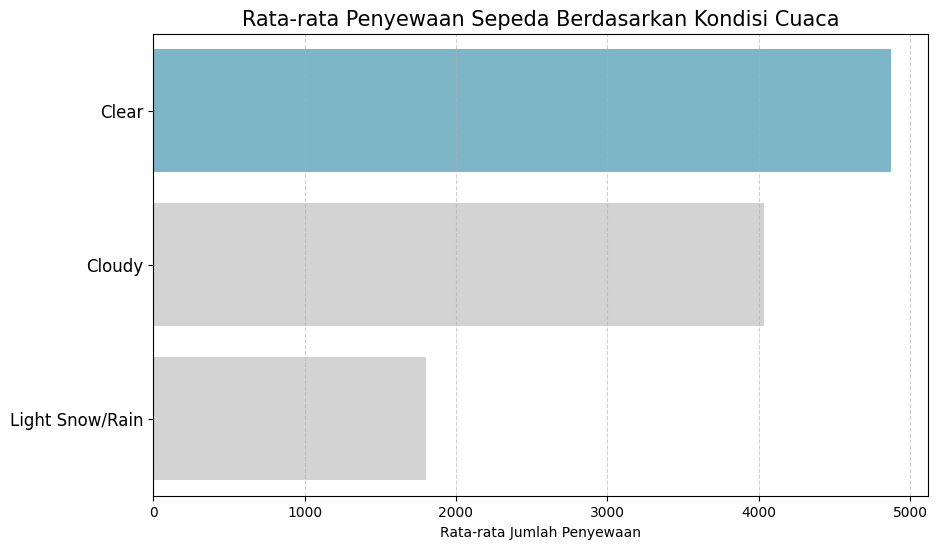

In [14]:
# Membuat visualisasi Bar Chart untuk pertanyaan bisnis 1
plt.figure(figsize=(10, 6))

# Menentukan warna: Biru cerah untuk yang tertinggi, abu-abu untuk lainnya
colors = ["#72BCD4", "#D3D3D3", "#D3D3D3"]

sns.barplot(
    x='cnt',
    y='weathersit',
    data=weather_rentals.sort_values(by='cnt', ascending=False),
    palette=colors
)

# Menambahkan Judul dan Label
plt.title('Rata-rata Penyewaan Sepeda Berdasarkan Kondisi Cuaca', loc='center', fontsize=15)
plt.ylabel(None)
plt.xlabel('Rata-rata Jumlah Penyewaan')
plt.tick_params(axis='y', labelsize=12)

# Menambahkan garis bantu (grid) pada sumbu x
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.show()

**Insight:**   
Berdasarkan analisis kondisi cuaca, terlihat jelas bahwa volume penyewaan sepeda sangat bergantung pada faktor kenyamanan lingkungan. Kondisi cuaca cerah (Clear) menjadi pendorong utama dengan rata-rata penyewaan mencapai 4.876 unit, yang merupakan angka tertinggi dibandingkan kondisi lainnya. Sebaliknya, ketika cuaca memburuk menjadi hujan ringan atau salju (Light Snow/Rain), jumlah penyewaan merosot tajam hingga angka 1.803 unit, atau berkurang lebih dari 60% dibandingkan saat cuaca cerah. Hal ini menunjukkan bahwa meskipun layanan ini populer, sensitivitas pengguna terhadap cuaca ekstrem sangatlah tinggi, sehingga operasional bisnis akan sangat fluktuatif mengikuti perubahan iklim harian.


### Pertanyaan 2:

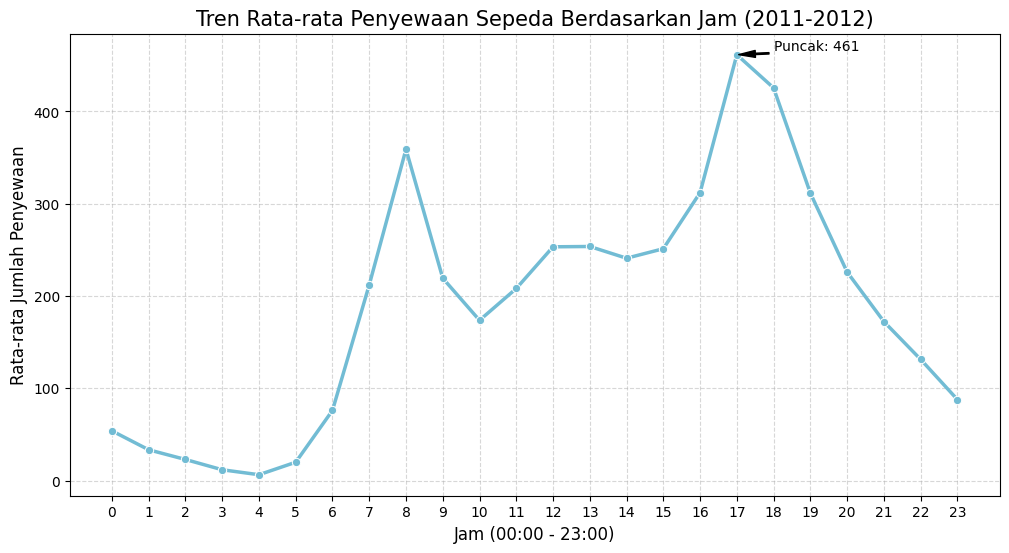

In [15]:
# Membuat visualisasi Line Chart
plt.figure(figsize=(12, 6))

sns.lineplot(
    x='hr',
    y='cnt',
    data=hourly_rentals,
    marker='o',
    linewidth=2.5,
    color='#72BCD4'
)

# Menambahkan judul dan label
plt.title('Tren Rata-rata Penyewaan Sepeda Berdasarkan Jam (2011-2012)', fontsize=15)
plt.xlabel('Jam (00:00 - 23:00)', fontsize=12)
plt.ylabel('Rata-rata Jumlah Penyewaan', fontsize=12)

# Mengatur agar semua angka jam (0-23) muncul di sumbu X
plt.xticks(range(0, 24))

# Menambahkan garis bantu (grid) agar lebih mudah membaca nilai
plt.grid(True, linestyle='--', alpha=0.5)

# Menambahkan anotasi pada titik tertinggi (pukul 17:00)
peak_hour = 17
peak_value = hourly_rentals.loc[hourly_rentals['hr'] == peak_hour, 'cnt'].values[0]
plt.annotate(f'Puncak: {peak_value:.0f}',
             xy=(peak_hour, peak_value),
             xytext=(peak_hour+1, peak_value+5),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))

plt.show()

**Insight:**   
Dari hasil visualisasi di atas, tren penyewaan berdasarkan jam mengungkapkan pola aktivitas yang sangat identik dengan perilaku komuter, di mana permintaan tidak tersebar merata melainkan terkonsentrasi pada waktu-waktu produktif. Terdapat dua puncak aktivitas yang sangat menonjol, yaitu pada pukul (08:00) pagi saat jam berangkat kerja dan pukul (17:00) sore saat jam kepulangan, dengan puncak tertinggi terjadi di sore hari mencapai rata-rata 461 penyewaan. Pola "dua puncak" pada grafik garis ini membuktikan bahwa sepeda telah menjadi sarana transportasi utama untuk mobilitas rutin harian, sementara jam-jam di luar puncak tersebut, terutama pada dini hari antara pukul 00:00 hingga 05:00, mencatatkan aktivitas terendah yang sekaligus menjadi waktu paling ideal bagi tim operasional untuk melakukan pemeliharaan.

## Analisis Lanjutan (Opsional)

/tmp/ipykernel_580/694020723.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


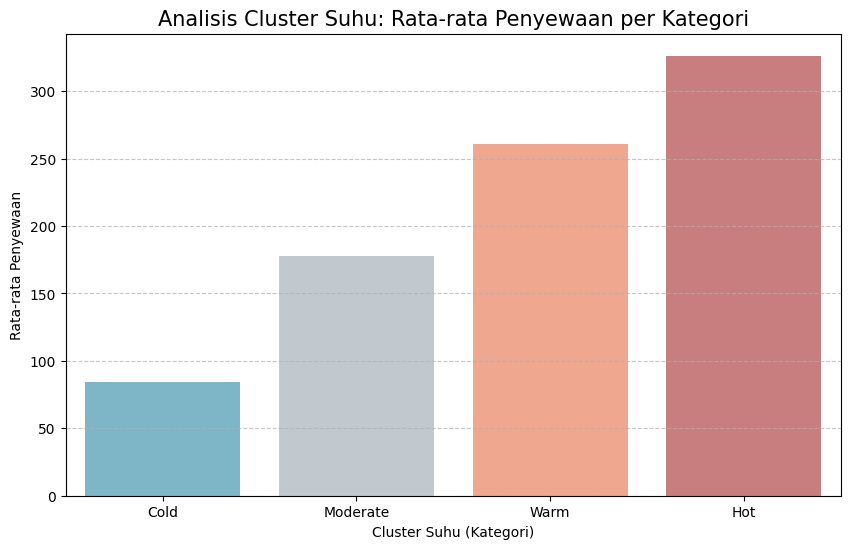

In [16]:
# Melakukan analisis lanjutan Clustering dengan menggunakan metode Binning
# Menentukan Range (Bin) dan Label
# Membagi suhu (temp) menjadi 4 kategori: Cold, Moderate, Warm, Hot
bins = [0, 0.3, 0.6, 0.8, 1.0]
labels = ['Cold', 'Moderate', 'Warm', 'Hot']

# Menerapkan Binning (Clustering Manual) dengan membuat kolom baru bernama 'temp_cluster'
hour_df['temp_cluster'] = pd.cut(hour_df['temp'], bins=bins, labels=labels, include_lowest=True)

# Agregasi Data berdasarkan Cluster
temp_cluster_analysis = hour_df.groupby('temp_cluster', observed=True).agg({
    'cnt': 'mean'
}).reset_index()

# Visualisasi Hasil Clustering
plt.figure(figsize=(10, 6))
colors = ["#72BCD4", "#BFCAD0", "#FF9F80", "#D47272"]

sns.barplot(
    x='temp_cluster',
    y='cnt',
    data=temp_cluster_analysis,
    palette=colors
)

# Menambahkan judul dan label
plt.title('Analisis Cluster Suhu: Rata-rata Penyewaan per Kategori', fontsize=15)
plt.xlabel('Cluster Suhu (Kategori)')
plt.ylabel('Rata-rata Penyewaan')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

## Conclusion

- Conclution pertanyaan 1: Kondisi cuaca merupakan faktor penentu paling dominan dalam volume penyewaan sepeda. Analisis menunjukkan bahwa cuaca cerah (Clear) adalah kondisi ideal yang menghasilkan rata-rata penyewaan tertinggi, yakni sekitar 4.877 unit per hari. Sebaliknya, terdapat penurunan drastis sebesar lebih dari 60% saat cuaca memburuk menjadi hujan ringan atau salju (Light Snow/Rain), di mana angka penyewaan merosot hingga ke kisaran 1.803 unit. Hal ini mengonfirmasi bahwa kenyamanan lingkungan memiliki korelasi positif yang sangat kuat dengan minat pengguna; semakin tinggi suhu yang dirasakan dan semakin cerah langit, semakin tinggi pula loyalitas pengguna terhadap layanan ini.
- Conclution pertanyaan 2: Pola penyewaan harian menunjukkan karakteristik "Double-Peak" yang sangat identik dengan siklus mobilitas komuter. Rata-rata penyewaan mencapai tingkat tertinggi pada dua periode kritis: pukul 08:00 pagi (saat jam berangkat kerja/sekolah) dan pukul 17:00 sore (saat jam kepulangan), dengan pukul 17:00 sebagai puncak sepanjang hari (rata-rata 461 unit). Kontras dengan jam sibuk tersebut, aktivitas berada pada titik terendah antara pukul 00:00 hingga 05:00 pagi. Temuan ini membuktikan bahwa layanan bike sharing ini bukan sekadar sarana rekreasi, melainkan infrastruktur transportasi vital bagi para pengguna terdaftar untuk mobilitas produktif mereka.

In [17]:
# Mengekspor hour_df.csv ke file utama main_data.csv
# File utama akan digunakan dalam pembuatan dashboard menggunakan streamlit
hour_df.to_csv("main_data.csv", index=False)